# Exercise 7 #
Perform cluster analysis on DJIA Index components using K-Means and build an equal weight
portfolio from the selected stocks. Retrieve the list of DJIA components; identify and clean any
missing data points. Cluster stocks based on weekly ATR and compare it with the original dataset.


Use pyfolio-reloaded library for portfolio statistics and visualization.

**𝐾-Means Clustering**
Clustering is a branch of unsupervised machine learning models that seeks to learn from the properties
of the data by identifying groups or clusters in the dataset.

The 𝑘-means algorithm searches for a predetermined number of clusters within an unlabeled dataset
and is based on the assumptions that the optimal cluster will have

### Import the libraries ###

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
# Import Libraries
import pandas as pd
import numpy as np
import pyfolio as pf
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load the pre-saved data dict
ohlc = np.load('data/dow_ohlc.npy', allow_pickle='TRUE').item()
ohlc['MMM'].head()

,Open,High,Low,Close,Volume
Date,,,,,
2009-12-31,62.906018,63.123738,61.967570,62.065166,2049800
2010-01-04,62.380479,62.650753,62.065162,62.327927,3043700
2010-01-05,62.162779,62.485606,61.336941,61.937550,2847000
2010-01-06,62.973588,63.514135,62.695811,62.815929,5268500
2010-01-07,62.553137,62.883472,61.652230,62.860950,4470100


In [6]:
ohlc['V'].tail()

,Open,High,Low,Close,Volume
Date,,,,,
2020-09-23,200.800003,201.089996,194.570007,195.369995,6310600
2020-09-24,195.149994,197.669998,193.130005,195.520004,9865300
2020-09-25,195.020004,198.139999,193.509995,197.250000,5496100
2020-09-28,200.630005,201.720001,199.830002,200.320007,5565300
2020-09-29,200.580002,202.380005,199.369995,199.440002,5513500


In [3]:
type(ohlc)

dict

In [9]:
type(ohlc['WMT'])

pandas.core.frame.DataFrame

ohlc is a dictionary that contains the price information of all the Dow Jones Index stocks from 2009-2020. The tag is the stock ticker, the value is a dataframe.

In [10]:
# List of DJIA stocks
dow_stocks = ['MMM', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO',
              'DOW', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'MRK', 'MSFT',
              'NKE', 'PG', 'CRM', 'TRV', 'UNH', 'VZ', 'V', 'WBA', 'WMT', 'DIS']

In [11]:
# Function to calculate average true range
def ATR(df,n):
    "function to calculate Average True Range"
    df = df.copy()
    
    df['H-L'] = abs(df['High']-df['Low'])
    df['H-PC'] = abs(df['High']-df['Close'].shift(1))
    df['L-PC'] = abs(df['Low']-df['Close'].shift(1))
    
    df['TR'] = df[['H-L','H-PC','L-PC']].max(axis=1,skipna=False)
    df['ATR'] = df['TR'].rolling(n).mean()
    
    df2 = df.drop(['H-L','H-PC','L-PC'],axis=1)
    return df2['ATR']

In [13]:
# Add ATR for each stocks
for symbol in dow_stocks:
    ohlc[symbol]['ATR'] = ATR(ohlc[symbol],21)

In [14]:
# Subsume into dataframe
df = pd.DataFrame({symbol: ohlc[symbol]['ATR'] for symbol in dow_stocks})
# Check for missing values
df.isnull().sum()

MMM       22
AXP       22
AMGN      22
AAPL      22
BA        22
CAT       43
CVX       22
CSCO      22
KO        22
DOW     2340
GS        22
HD        22
HON       22
IBM       22
INTC      22
JNJ       22
JPM       22
MCD       22
MRK       22
MSFT      22
NKE       22
PG        22
CRM       22
TRV       22
UNH       22
VZ        22
V         22
WBA       22
WMT       22
DIS       22
dtype: int64

In [15]:
df.head()

,MMM,AXP,AMGN,AAPL,BA,CAT,CVX,CSCO,KO,DOW,...,NKE,PG,CRM,TRV,UNH,VZ,V,WBA,WMT,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Fill forward the missing values and drop DOW company from the list
df.fillna(method='bfill', axis=0, inplace=True)
df.drop(['DOW'], axis=1, inplace=True)

In [19]:
df[20:25]

,MMM,AXP,AMGN,AAPL,BA,CAT,CVX,CSCO,KO,GS,...,NKE,PG,CRM,TRV,UNH,VZ,V,WBA,WMT,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-01,1.113625,1.035185,0.944033,0.189773,1.420966,1.533670,0.948067,0.455210,0.292113,4.401394,...,0.189408,0.743231,0.498452,0.793992,0.958508,0.364106,0.413464,0.506632,0.632319,0.537549
2010-02-02,1.113625,1.035185,0.944033,0.189773,1.420966,1.533670,0.948067,0.455210,0.292113,4.401394,...,0.189408,0.743231,0.498452,0.793992,0.958508,0.364106,0.413464,0.506632,0.632319,0.537549
2010-02-03,1.151878,1.040187,0.915368,0.192727,1.372968,1.488806,0.922552,0.437260,0.295279,4.303309,...,0.187930,0.738587,0.499286,0.795086,0.962939,0.376221,0.424010,0.576119,0.624657,0.545845
2010-02-04,1.192634,1.050500,0.926452,0.200545,1.370946,1.517021,0.961926,0.449825,0.304304,4.429060,...,0.195409,0.761429,0.518214,0.786328,0.972603,0.375117,0.436119,0.612150,0.649467,0.571975
2010-02-05,1.197639,1.072190,0.945562,0.201530,1.389642,1.531543,0.993737,0.461313,0.311270,4.559695,...,0.200540,0.774297,0.532262,0.785598,0.978242,0.359247,0.456529,0.586781,0.662602,0.593958


In [20]:
# Resample to a weekly timeframe for cluster analysis
px = df.resample('W-FRI').mean()
px = px.T
# Check output
px.head(2)

Date,2010-01-01,2010-01-08,2010-01-15,2010-01-22,2010-01-29,2010-02-05,2010-02-12,2010-02-19,2010-02-26,2010-03-05,...,2020-07-31,2020-08-07,2020-08-14,2020-08-21,2020-08-28,2020-09-04,2020-09-11,2020-09-18,2020-09-25,2020-10-02
MMM,1.113625,1.113625,1.113625,1.113625,1.113625,1.153880,1.233820,1.308653,1.232967,1.071002,...,3.304308,3.337810,3.339979,3.176965,2.863492,2.869821,3.166674,3.413893,4.169714,4.322380
AXP,1.035185,1.035185,1.035185,1.035185,1.035185,1.046649,1.079262,1.101860,0.908801,0.774188,...,2.843043,2.639048,2.661429,2.715334,2.638858,2.682953,2.666072,2.634953,3.009524,3.067619


In [22]:
px.T.head()

,MMM,AXP,AMGN,AAPL,BA,CAT,CVX,CSCO,KO,GS,...,NKE,PG,CRM,TRV,UNH,VZ,V,WBA,WMT,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.113625,1.035185,0.944033,0.189773,1.420966,1.53367,0.948067,0.45521,0.292113,4.401394,...,0.189408,0.743231,0.498452,0.793992,0.958508,0.364106,0.413464,0.506632,0.632319,0.537549
2010-01-08,1.113625,1.035185,0.944033,0.189773,1.420966,1.53367,0.948067,0.45521,0.292113,4.401394,...,0.189408,0.743231,0.498452,0.793992,0.958508,0.364106,0.413464,0.506632,0.632319,0.537549
2010-01-15,1.113625,1.035185,0.944033,0.189773,1.420966,1.53367,0.948067,0.45521,0.292113,4.401394,...,0.189408,0.743231,0.498452,0.793992,0.958508,0.364106,0.413464,0.506632,0.632319,0.537549
2010-01-22,1.113625,1.035185,0.944033,0.189773,1.420966,1.53367,0.948067,0.45521,0.292113,4.401394,...,0.189408,0.743231,0.498452,0.793992,0.958508,0.364106,0.413464,0.506632,0.632319,0.537549
2010-01-29,1.113625,1.035185,0.944033,0.189773,1.420966,1.53367,0.948067,0.45521,0.292113,4.401394,...,0.189408,0.743231,0.498452,0.793992,0.958508,0.364106,0.413464,0.506632,0.632319,0.537549


### Elbow Plot ###
The number of clusters is a hyperparameter to clustering models and choose the
optimal number of clusters is critical for the model. We identify the elbow point programmatically
for this exercise.

In [23]:
scaler = MinMaxScaler()
scaled_px = scaler.fit_transform(px)

**Inertia** is calculated by measuring the distance between each data point and its centroid, squaring this distance, and summing these squares across one cluster. A good model is one with low inertia AND a low number of clusters ( K ). However, this is a tradeoff because as K increases, inertia decreases.

In [24]:
# Get the inertia
sse = []
for k in range(1, 30):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_px)
    sse.append(kmeans.inertia_)
    
# Knee Locator
kl = KneeLocator(range(1, 30), sse, curve="convex", direction="decreasing")
kl.elbow

np.int64(6)

In [27]:
print(sse)

[829.9003415825297, 412.6330319495908, 331.3808423392729, 266.3994255071482, 201.35385322005777, 135.4006212174311, 118.40482548824136, 114.47656126018684, 95.27496887646934, 72.25686667434422, 59.81486423897263, 50.07912742330449, 41.67399083677915, 37.57058754741723, 28.60652839916996, 23.58534160709562, 20.565297330198216, 18.79451287354997, 13.89749524865756, 11.96981693410411, 10.104015644646996, 8.465648182089343, 7.343901435014313, 4.695728332937222, 3.4748764237066982, 2.5511819683677754, 1.3418314604591681, 0.4224063298809029, 0.0]


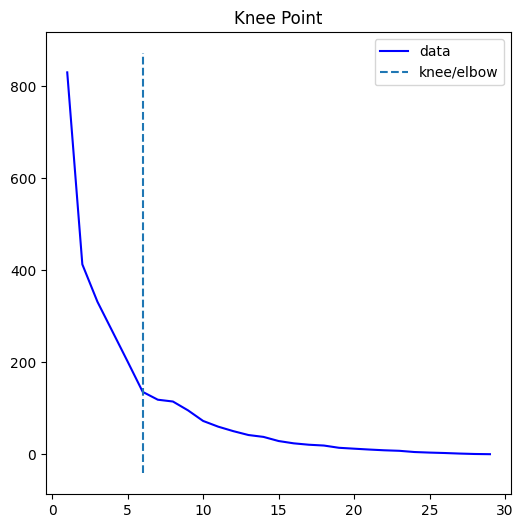

In [25]:
# Raw data and knee.
kl.plot_knee()

### Build Clusters ###
We will now fit the cluster model.

In [28]:
# Build clusters
model = KMeans(n_clusters=6)
model.fit(scaled_px)
labels = model.predict(scaled_px)
labels

array([1, 2, 5, 0, 4, 1, 1, 0, 0, 3, 1, 2, 1, 0, 2, 2, 2, 0, 2, 0, 2, 1,
       2, 1, 0, 2, 2, 2, 2], dtype=int32)

In [30]:
# Remove DOW from the list
companies = dow_stocks
companies.remove('DOW')

In [32]:
df1 = pd.DataFrame({'Cluster': labels,
                    'Companies': companies,
                    'ATR': px.mean(axis=1),
                   }).sort_values(by=['Cluster'], axis = 0)
df1 = df1.reset_index(drop=True)
df1

,Cluster,Companies,ATR
0,0,KO,0.493262
1,0,INTC,0.695828
2,0,NKE,0.969232
3,0,CSCO,0.538751
4,0,MRK,0.865679
5,0,AAPL,0.680922
6,0,VZ,0.606684
7,1,CAT,2.079966
8,1,CVX,1.630457
9,1,UNH,2.748506


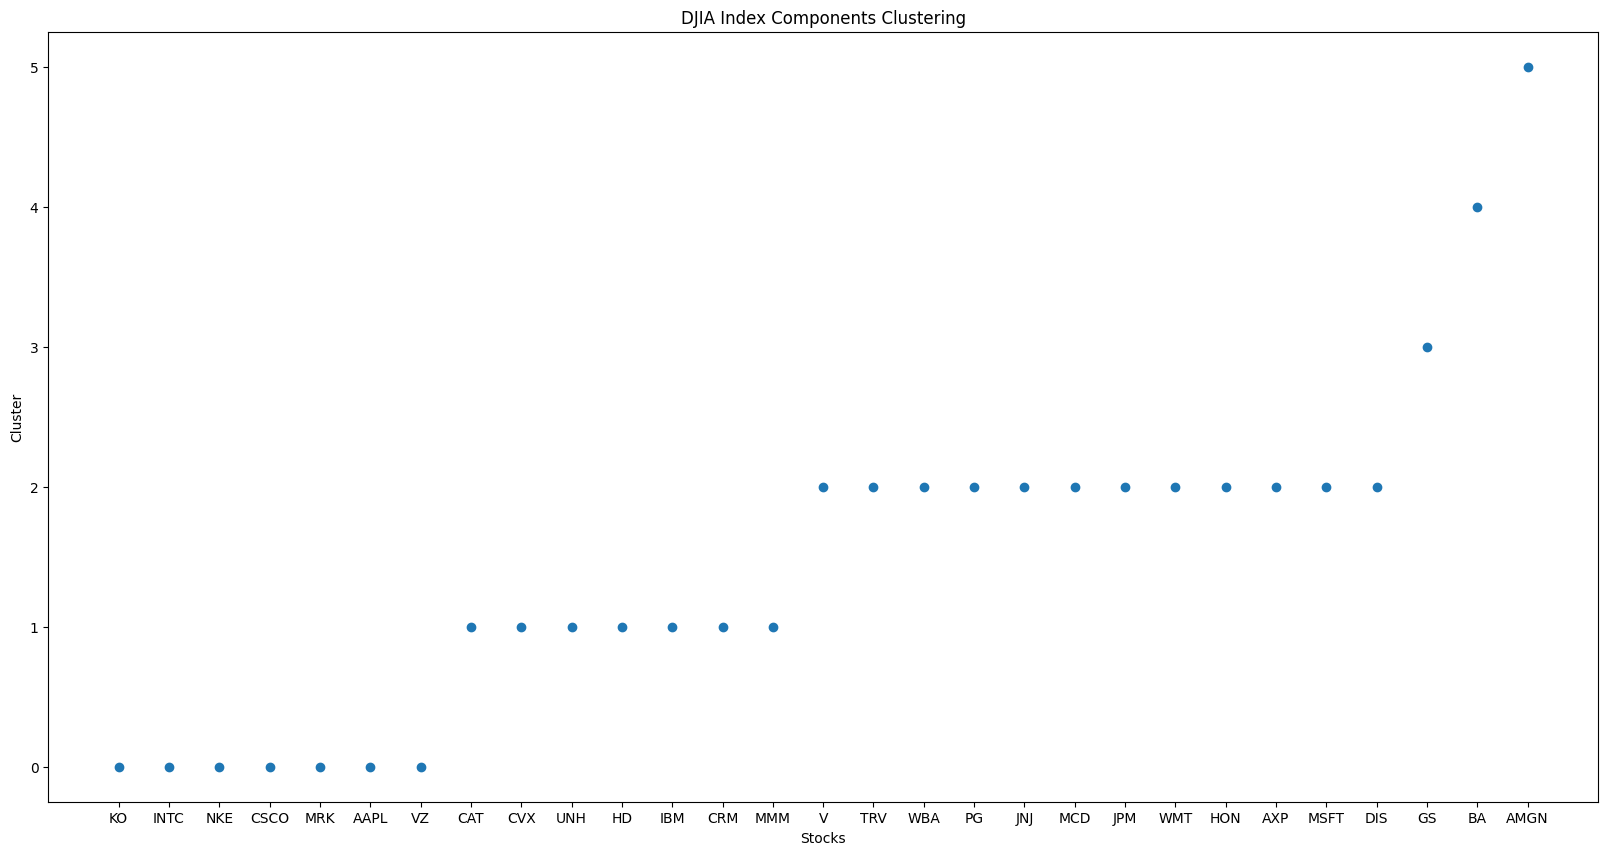

In [33]:
# Plot Clusters
plt.figure(figsize=(20,10))
plt.scatter(df1.Companies, df1.Cluster)
plt.xlabel('Stocks')
plt.ylabel('Cluster')
plt.title('DJIA Index Components Clustering');

**Portfolio Construction**

Shortlisting the six stocks from the above clusters (one for each), we
will now build a portfolio and compare the returns with all stock portfolio.

In [34]:
# Cluster portfolio stocks
portfolio_stocks = ['GS', 'JNJ', 'UNH', 'CSCO', 'CRM', 'AMGN']
port = pd.DataFrame({symbol: ohlc[symbol]['Close'] for symbol in portfolio_stocks})
port.dropna(inplace=True)
port

,GS,JNJ,UNH,CSCO,CRM,AMGN
Date,,,,,,
2009-12-31,144.296997,46.714996,25.778193,18.048286,18.442499,45.404182
2010-01-04,147.920776,46.910812,26.666224,18.613705,18.705000,46.327202
2010-01-05,150.535919,46.366856,26.623932,18.530785,18.625000,45.925884
2010-01-06,148.929138,46.743999,26.886124,18.410154,18.592501,45.580757
2010-01-07,151.843475,46.410374,27.917923,18.493084,18.510000,45.163395
...,...,...,...,...,...,...
2020-09-23,186.119995,144.440002,292.140015,37.930145,235.990005,242.589996
2020-09-24,195.110001,144.669998,292.660004,37.504074,237.550003,240.320007
2020-09-25,194.949997,145.660004,302.500000,38.098591,242.740005,243.820007


In [35]:
# Calculate portfolio returns
portfolio_returns = port.pct_change().fillna(0)
port['Returns'] = portfolio_returns.mean(axis=1)
port.head(2)

,GS,JNJ,UNH,CSCO,CRM,AMGN,Returns
Date,,,,,,,
2009-12-31,144.296997,46.714996,25.778193,18.048286,18.442499,45.404182,0.000000
2010-01-04,147.920776,46.910812,26.666224,18.613705,18.705000,46.327202,0.021607


Start date,2009-12-31
End date,2020-09-29
Total months,128
,Backtest
Annual return,17.1%
Cumulative returns,445.0%
Annual volatility,19.5%
Sharpe ratio,0.91
Calmar ratio,0.57
Stability,0.98
Max drawdown,-29.8%


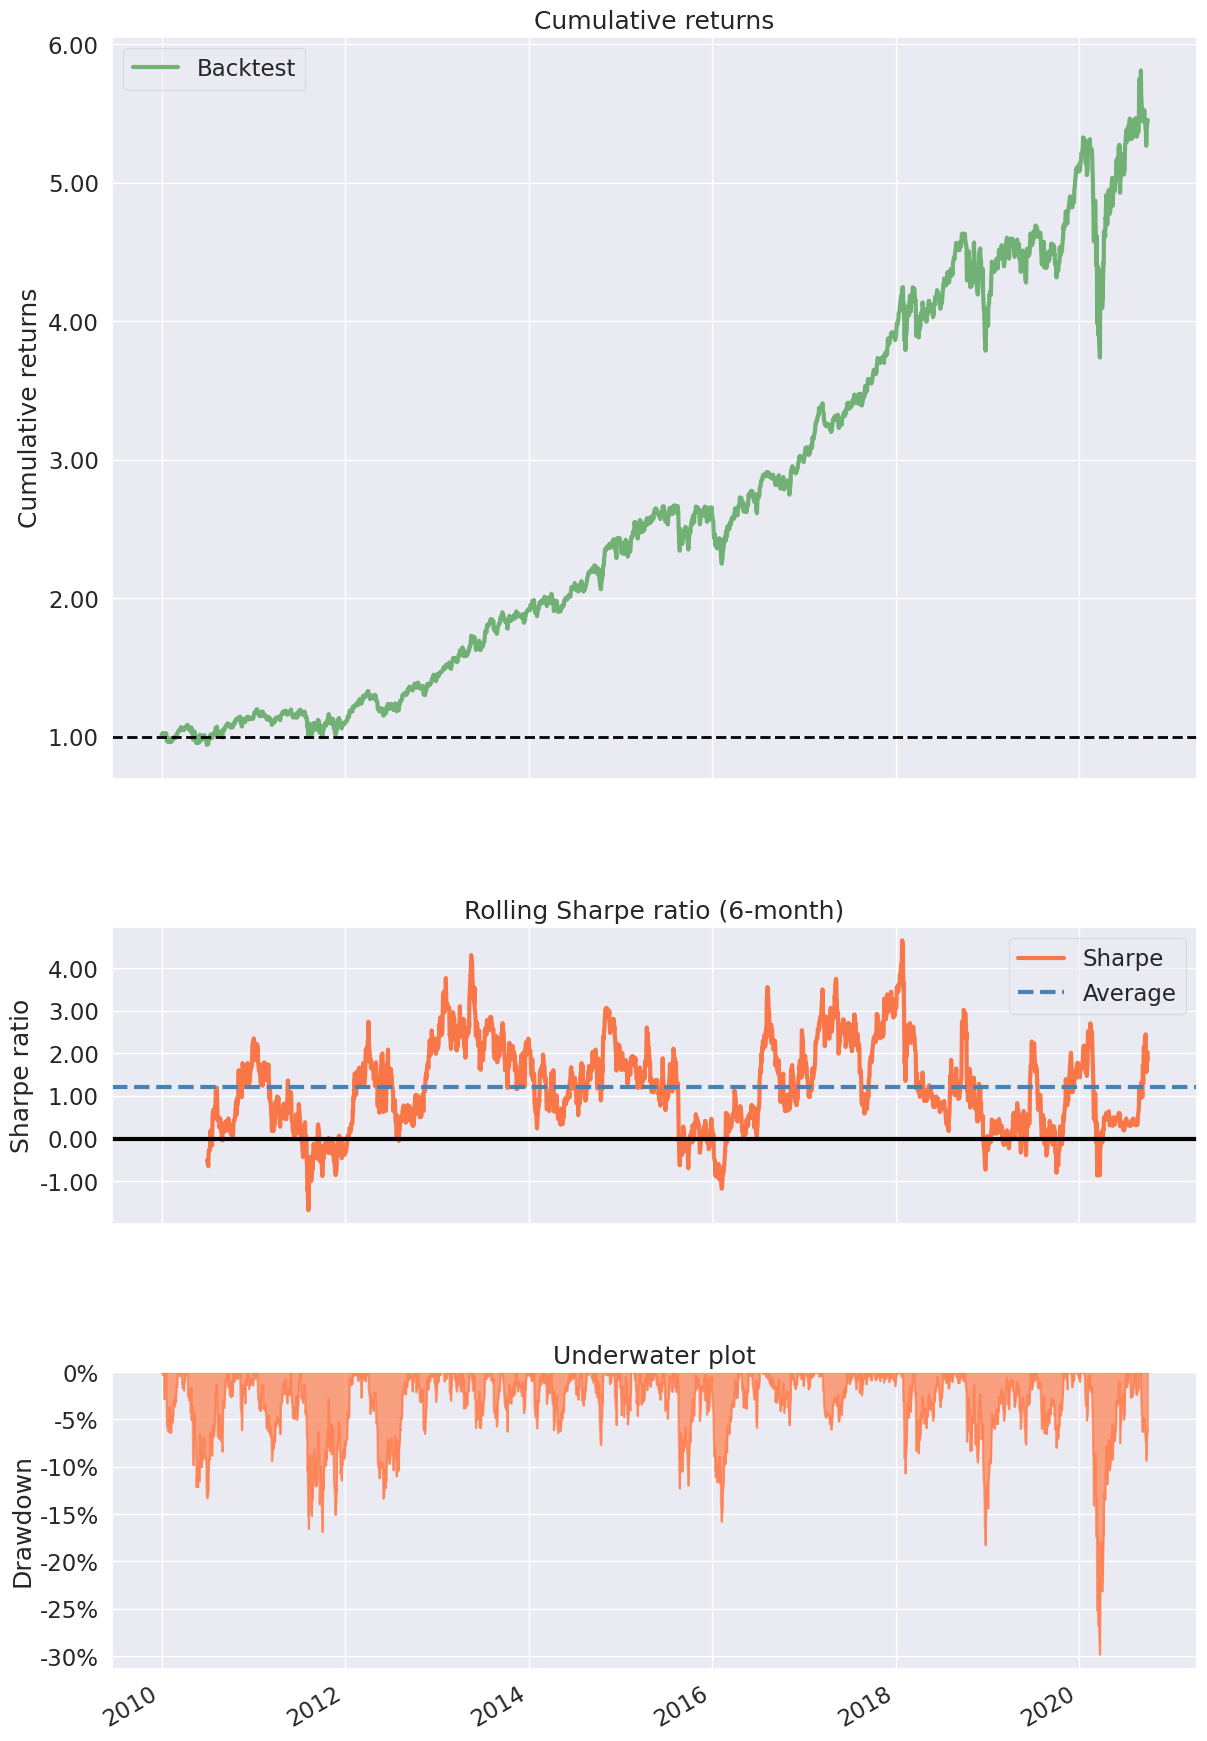

In [36]:
# Create Tear sheet using pyfolio
pf.create_simple_tear_sheet(port['Returns'])

In [37]:
# All stocks portfolio
all_stocks = pd.DataFrame({symbol: ohlc[symbol]['Close'] for symbol in companies})
all_stocks.dropna(inplace=True)
all_stocks.head(2)

,MMM,AXP,AMGN,AAPL,BA,CAT,CVX,CSCO,KO,GS,...,NKE,PG,CRM,TRV,UNH,VZ,V,WBA,WMT,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-31,62.065166,34.434761,45.404182,6.503574,41.856789,41.498463,50.924435,18.048286,18.951757,144.296997,...,12.066024,43.431492,18.442499,38.205708,25.778193,18.633041,17.935587,28.350834,40.954620,28.090706
2010-01-04,62.327927,34.774685,46.327202,6.604801,43.441975,42.634403,52.293617,18.613705,18.965061,147.920776,...,11.934528,43.782478,18.705000,38.167397,26.666224,18.717409,18.075037,28.798639,41.552284,27.933924


In [38]:
# Calculate all stocks portfolio returns
all_stocks_returns = all_stocks.pct_change().fillna(0)
all_stocks['Returns'] = all_stocks_returns.mean(axis=1)
all_stocks.head(2)

,MMM,AXP,AMGN,AAPL,BA,CAT,CVX,CSCO,KO,GS,...,PG,CRM,TRV,UNH,VZ,V,WBA,WMT,DIS,Returns
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-31,62.065166,34.434761,45.404182,6.503574,41.856789,41.498463,50.924435,18.048286,18.951757,144.296997,...,43.431492,18.442499,38.205708,25.778193,18.633041,17.935587,28.350834,40.954620,28.090706,0.000000
2010-01-04,62.327927,34.774685,46.327202,6.604801,43.441975,42.634403,52.293617,18.613705,18.965061,147.920776,...,43.782478,18.705000,38.167397,26.666224,18.717409,18.075037,28.798639,41.552284,27.933924,0.013946


Start date,2009-12-31
End date,2020-09-29
Total months,128
,Backtest
Annual return,15.9%
Cumulative returns,385.9%
Annual volatility,17.2%
Sharpe ratio,0.94
Calmar ratio,0.48
Stability,0.98
Max drawdown,-33.1%


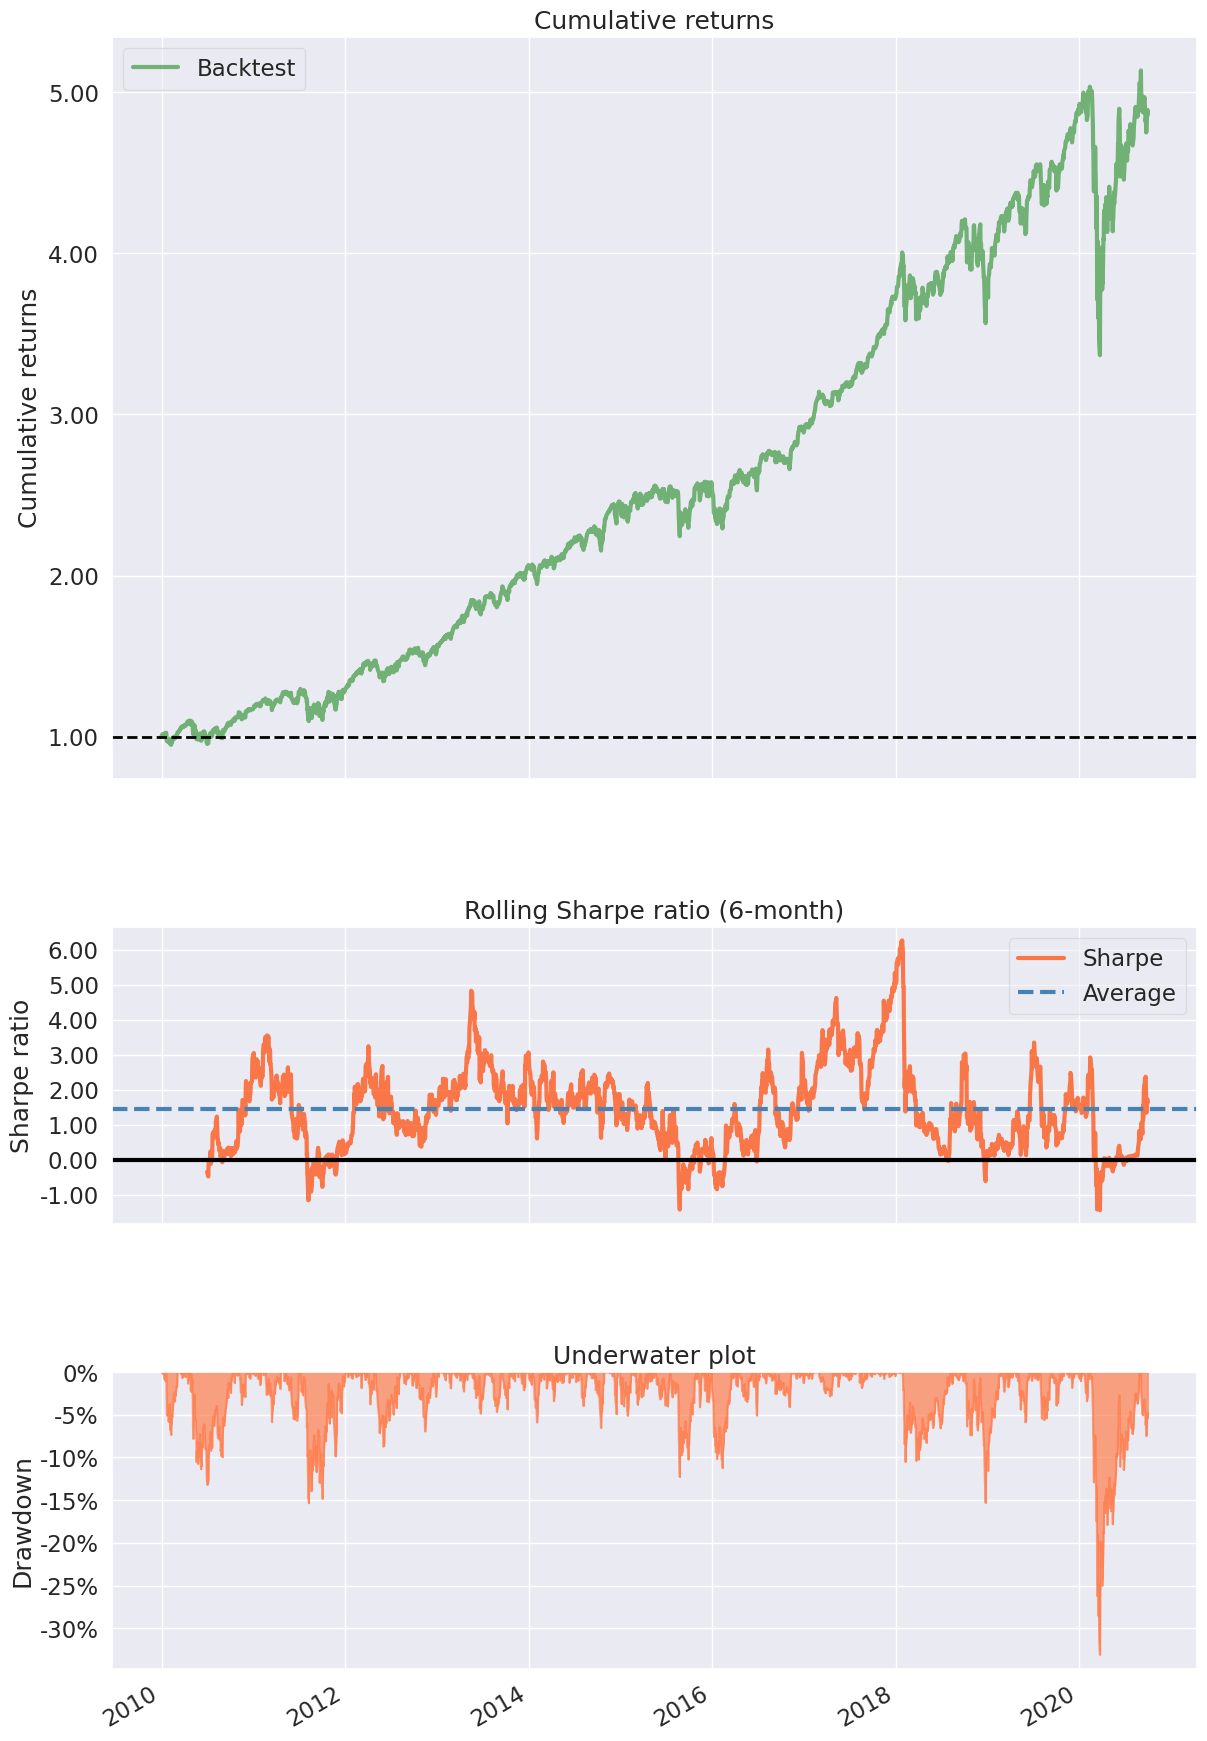

In [39]:
# Create Tear sheet using pyfolio
pf.create_simple_tear_sheet(all_stocks['Returns'])
plt.show()

**Conclusion**

The cluster stocks generated a CAGR of 17% with a maximum drawdown of ~30%
while the all stocks portfolio consisting of 29 DJIA index stocks generated an annualized return of
~16% with a maximum drawdown of 33%. This study highlight that with 20% of all stocks, we
can construct a portfolio that can outperform the all stocks portfolio with an alpha of 59% and an
improved sortino ratio.


Note:
1. The data is not treated for in/out sample as the objective here is to showcase the application
of clustering methods. Accordingly, the actual results may vary.
2. Arbitrary selection of Cluster stocks can be avoided by adopting a minimum distance measure
in stock selection.